<a href="https://colab.research.google.com/github/swadhaaryama/Algorithim/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# This tells the computer to look at the file you just uploaded
data = pd.read_csv('diabetic_data.csv')

# Let's see if it worked!
print("Success! I have the data.")
print(f"The dataset has {data.shape[0]} rows and {data.shape[1]} columns.")
display(data.head())

Success! I have the data.
The dataset has 101766 rows and 50 columns.


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
import numpy as np

# 1. Replace '?' with a format the computer understands (NaN)
data_clean = data.replace('?', np.nan)

# 2. Check which columns have the most missing '?' marks
missing_info = data_clean.isnull().sum()
print("Missing values per column:")
print(missing_info[missing_info > 0])

# 3. If a column has TOO many missing values (like 'weight'), we drop it
data_clean = data_clean.drop(columns=['weight', 'payer_code', 'medical_specialty'])

print("\nCleanup Complete! We removed columns that were mostly empty.")

Missing values per column:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

Cleanup Complete! We removed columns that were mostly empty.


In [ ]:
# 1. We want to predict if someone is readmitted.
# Let's simplify: 1 if they came back within 30 days, 0 if they didn't.
data_clean['target'] = data_clean['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# 2. Let's look at the "Result" - How many people actually came back?
print("How many people were readmitted within 30 days?")
print(data_clean['target'].value_counts())

# 3. Choose the 'ingredients' (Features) we want to use for our prediction
# We'll pick simple ones for now: age, time in hospital, and number of lab procedures.
features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications']
X = data_clean[features]
y = data_clean['target']

print("\nReady! We have our 'Ingredients' (X) and our 'Answer Key' (y).")

How many people were readmitted within 30 days?
target
0    90409
1    11357
Name: count, dtype: int64

Ready! We have our 'Ingredients' (X) and our 'Answer Key' (y).


In [ ]:
from sklearn.model_selection import train_test_split

# We split the data: 80% for training the brain, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set has {len(X_train)} patients.")
print(f"Testing set has {len(X_test)} patients.")

Training set has 81412 patients.
Testing set has 20354 patients.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Create the 'Brain' (The Model)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Let the Brain study the training data
print("Training the Random Forest... please wait...")
model.fit(X_train, y_train)

# 3. Now, ask the Brain to guess the answers for the test data
predictions = model.predict(X_test)

# 4. Check the score!
accuracy = accuracy_score(y_test, predictions)
print(f"\nWork Complete! The model's Accuracy is: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, predictions))

Training the Random Forest... please wait...

Work Complete! The model's Accuracy is: 86.02%

Detailed Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     18069
           1       0.13      0.04      0.06      2285

    accuracy                           0.86     20354
   macro avg       0.51      0.50      0.49     20354
weighted avg       0.80      0.86      0.83     20354



In [ ]:
from xgboost import XGBClassifier

# 1. Create the XGBoost Brain
xgb_model = XGBClassifier()

# 2. Train it
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Predict
xgb_predictions = xgb_model.predict(X_test)

# 4. Score
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")

Training XGBoost...
XGBoost Accuracy: 88.76%


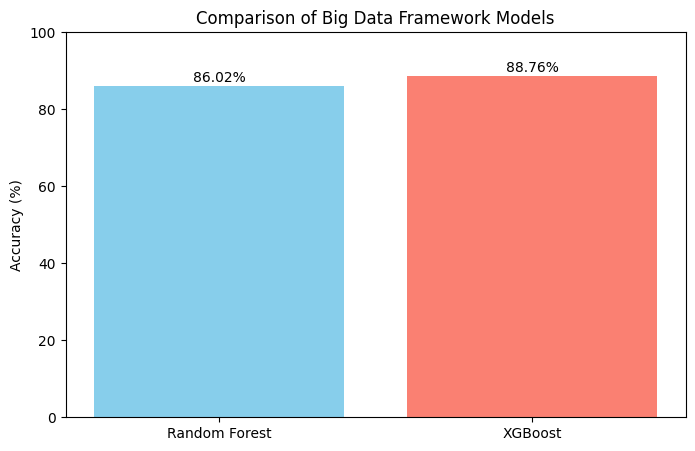

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare the data for the graph
models = ['Random Forest', 'XGBoost']
accuracies = [accuracy * 100, xgb_accuracy * 100]

# 2. Create the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon'])

# 3. Add labels and title
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Big Data Framework Models')
plt.ylim(0, 100) # Sets the scale from 0 to 100

# Add the percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center')

plt.show()

In [ ]:
# See which factors the Random Forest thought were most important
importances = model.feature_importances_
for i, v in enumerate(importances):
    print(f'Feature: {features[i]}, Score: {v:.5f}')

Feature: time_in_hospital, Score: 0.12717
Feature: num_lab_procedures, Score: 0.50789
Feature: num_procedures, Score: 0.08549
Feature: num_medications, Score: 0.27946
